In [36]:
#Importing
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Dense,Dropout,Activation,Add,MaxPooling2D,Conv2D,Flatten,BatchNormalization,MaxPool2D
from keras.models import Sequential
import matplotlib.pyplot as plt
from keras.preprocessing import image

In [37]:
#Getting data
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "Accumulated", labels='inferred', label_mode="categorical", class_names=None,
    color_mode="grayscale", batch_size=32, image_size=(28, 28), shuffle=True, seed=123,
    validation_split=0.2, subset="training"
)
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "Accumulated", labels='inferred', label_mode="categorical", class_names=None,
    color_mode="grayscale", batch_size=32, image_size=(28, 28), shuffle=True, seed=123,
    validation_split=0.2, subset="validation"
)

Found 10600 files belonging to 7 classes.
Using 8480 files for training.
Found 10600 files belonging to 7 classes.
Using 2120 files for validation.


In [38]:
#Creating model
model = Sequential()
model.add(BatchNormalization())
model.add(Conv2D(32, kernel_size=(3,3), activation = 'relu', input_shape=(28,28 ,1) ))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Conv2D(16, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))
model.add(Flatten())
model.add(Dense(128, activation = 'relu'))
model.add(Dropout(0.20))
model.add(Dense(7, activation = 'softmax'))

In [39]:
#Model compilation
model.compile(optimizer='Adam', metrics=['accuracy'], loss='categorical_crossentropy')
call = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True)

In [40]:
#Training the model
fit= model.fit(train_data,validation_data=val_data,epochs=10,callbacks=[call])

Epoch 1/10
265/265 [==============================] - 56s 212ms/step - loss: 0.8356 - accuracy: 0.6613 - val_loss: 0.4867 - val_accuracy: 0.7627
Epoch 2/10
265/265 [==============================] - 19s 71ms/step - loss: 0.4089 - accuracy: 0.7945 - val_loss: 0.3403 - val_accuracy: 0.8014
Epoch 3/10
265/265 [==============================] - 19s 70ms/step - loss: 0.3133 - accuracy: 0.8297 - val_loss: 0.2975 - val_accuracy: 0.8132
Epoch 4/10
265/265 [==============================] - 20s 74ms/step - loss: 0.2698 - accuracy: 0.8414 - val_loss: 0.2837 - val_accuracy: 0.8151
Epoch 5/10
265/265 [==============================] - 19s 73ms/step - loss: 0.2488 - accuracy: 0.8421 - val_loss: 0.2552 - val_accuracy: 0.8208
Epoch 6/10
265/265 [==============================] - 19s 71ms/step - loss: 0.2333 - accuracy: 0.8508 - val_loss: 0.2592 - val_accuracy: 0.8269
Epoch 7/10
265/265 [==============================] - 18s 69ms/step - loss: 0.2227 - accuracy: 0.8545 - val_loss: 0.2648 - val_accuracy

In [29]:
#Data for plots
acc = fit.history['accuracy']
val_acc = fit.history['val_accuracy']
loss = fit.history['loss']
val_loss = fit.history['val_loss']
epochs = range(1, len(loss) + 1)

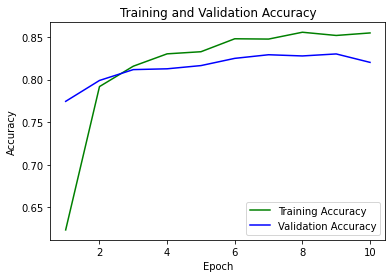

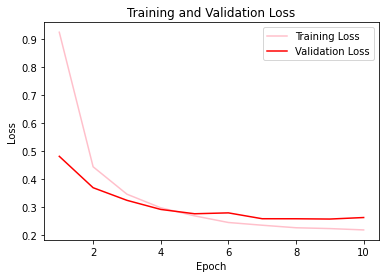

<Figure size 432x288 with 0 Axes>

In [30]:
#accuracy plot
plt.plot(epochs, acc, color='green', label='Training Accuracy')
plt.plot(epochs, val_acc, color='blue', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.figure()
#loss plot
plt.plot(epochs, loss, color='pink', label='Training Loss')
plt.plot(epochs, val_loss, color='red', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.figure()
plt.show()